Jonathon Tucker Final Project

# Imports

In [7]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import re
import io

from IPython.display import display as ipy_display, Image as IPyImage
from torchvision import datasets, transforms

## Transformer and loading training data

In [3]:
transform = transforms.Compose([torchvision.transforms.ToTensor(), torchvision.transforms.Normalize((0.5,), (0.5,))]) #transform image data into tensors (mean 0.5 sd 0.5)

train_set = torchvision.datasets.MNIST(root='~/.pytorch/MNIST_data/', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=32, shuffle=True)

#test_set = torchvision.datasets.MNIST(root='~/.pytorch/MNIST_data/', train=False, download=True, transform=transform)
#test_loader = torch.utils.data.DataLoader(test_set, batch_size=64, shuffle=False)

## Examine MINST Data

In [4]:
#Examine Data Set
print('Number of images in the training dataset:', len(train_set))
print(f"Shape of the images in the training dataset: {train_loader.dataset[0][0].shape}")

Number of images in the training dataset: 60000
Shape of the images in the training dataset: torch.Size([1, 28, 28])


# BuildNN — Neural Network Foundations

## Using Pytorch nn as Neural Network Construction

In [10]:
## Your solution here
import torch.nn.functional as F

class Network(nn.Module):
    def __init__(self):
        super().__init__()
        # Inputs to hidden layer linear transformation
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
    
        # Output layer, 10 units - one for each digit
        self.output = nn.Linear(64, 10)
        
    def forward(self, x):
        # Hidden layer with sigmoid activation
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        # Output layer with softmax activation
        x = F.softmax(self.output(x), dim=1)
        
        return x
model = Network()
print("Layers:")
print(model)

Layers:
Network(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=10, bias=True)
)


## Weight Initialization

In [ ]:
for layer in model:
    if isinstance(layer, nn.Linear):
        nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
        nn.init.constant_(layer.bias, 0.01)

print('Weight init applied (Kaiming normal, bias=0.01)')
for i, layer in enumerate(model):
    if isinstance(layer, nn.Linear):
        print(f'  Layer {i}: weight std={layer.weight.data.std():.4f}, bias mean={layer.bias.data.mean():.4f}')

## Feed-Forward Pass (Before Training)

With random weights the outputs are nearly uniform — no useful predictions yet.

In [14]:
# Grab some data 
dataiter = iter(train_loader)
#images, labels = dataiter.next()  # older version
images, labels = dataiter.__next__()

# Resize images into a 1D vector, new shape is (batch size, color channels, image pixels) 
images.resize_(64, 1, 784)
# or images.resize_(images.shape[0], 1, 784) to automatically get batch size
# we used a different way to flatten it earlier

# Forward pass through the network
img_idx = 5
ps = model.forward(images[img_idx,:])
print(images[img_idx,:].shape)

img = images[img_idx]


torch.Size([1, 784])


## `nn.Sequential`

In [ ]:
input_size   = 784
hidden_sizes = [256, 128, 64]
output_size  = 10

model = nn.Sequential(
    nn.Linear(input_size, hidden_sizes[0]),
    nn.ReLU(),
    nn.Linear(hidden_sizes[0], hidden_sizes[1]),
    nn.ReLU(),
    nn.Linear(hidden_sizes[1], hidden_sizes[2]),
    nn.ReLU(),
    nn.Linear(hidden_sizes[2], output_size),
    nn.LogSoftmax(dim=1)
)
print(model)
# Forward pass through the network and display output
images, labels = next(iter(train_loader))
images.resize_(images.shape[0], 1, 784)
ps = model.forward(images[0,:])

## Named Layers with `OrderedDict`

In [16]:
from collections import OrderedDict

net_named = nn.Sequential(OrderedDict([
    ('fc1',     nn.Linear(input_size, hidden_sizes[0])),
    ('relu1',   nn.ReLU()),
    ('fc2',     nn.Linear(hidden_sizes[0], hidden_sizes[1])),
    ('relu2',   nn.ReLU()),
    ('output',  nn.Linear(hidden_sizes[1], output_size)),
    ('softmax', nn.Softmax(dim=1))
]))
print(net_named)
print('\nAccess by index:', net_named[0])
print('Access by name: ', net_named.fc1)

Sequential(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (output): Linear(in_features=64, out_features=10, bias=True)
  (softmax): Softmax(dim=1)
)

Access by index: Linear(in_features=784, out_features=128, bias=True)
Access by name:  Linear(in_features=784, out_features=128, bias=True)


### BELOW IS NOT ON BUILD NN

# Train NN

In [23]:
# Training
loss_function = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
for epoch in range(epochs):
    for images, labels in train_loader:
        optimizer.zero_grad()
        images = images.view(images.shape[0], -1) 
        output = model(images)
        loss = loss_function(output, labels)
        loss.backward()
        optimizer.step()
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [1/10], Loss: 0.0035
Epoch [2/10], Loss: 0.0655
Epoch [3/10], Loss: 0.0108
Epoch [4/10], Loss: 0.0915
Epoch [5/10], Loss: 0.0947
Epoch [6/10], Loss: 0.0137
Epoch [7/10], Loss: 0.0035
Epoch [8/10], Loss: 0.0253
Epoch [9/10], Loss: 0.0142
Epoch [10/10], Loss: 0.0273


# Test Model

## Load Class Dataset

In [33]:
from pathlib import Path
from PIL import Image

path = Path('Handwritten-Digits-Spring-2026/digits')

# Define transform
pipe = transforms.Compose([transforms.Grayscale(1), transforms.Resize((28, 28)), 
                           transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# Filter and process
files = sorted([f for f in path.iterdir() if f.suffix.lower() in ('.png', '.jpg')])
images_list = [pipe(Image.open(f)).view(784) for f in files]
labels_list = [int(f.name.split('-')[0]) for f in files]

class_images = torch.stack(images_list)
class_labels = torch.tensor(labels_list)

print(f'Loaded {len(labels_list)} images; Shape: {class_images.shape}')
print('Label counts:', dict(zip(*np.unique(class_labels.numpy(), return_counts=True))))

Loaded 290 images; Shape: torch.Size([290, 784])
Label counts: {0: 29, 1: 29, 2: 29, 3: 29, 4: 29, 5: 29, 6: 29, 7: 29, 8: 29, 9: 29}


In [27]:
# Run test on class dataset
model.eval()
with torch.no_grad():
    output = model(class_images)
    _, predicted = torch.max(output, 1)

correct = (predicted == class_labels).sum().item()
total = len(class_labels)
print(f'Accuracy on class dataset: {100 * correct / total:.2f}% ({correct}/{total})')
print()
print('Per-digit accuracy:')
for digit in range(10):
    mask = class_labels == digit
    if mask.sum() > 0:
        d_correct = (predicted[mask] == class_labels[mask]).sum().item()
        d_total = mask.sum().item()
        print(f'  Digit {digit}: {d_correct}/{d_total} ({100*d_correct/d_total:.1f}%)')

Accuracy on class dataset: 54.48% (158/290)

Per-digit accuracy:
  Digit 0: 20/29 (69.0%)
  Digit 1: 8/29 (27.6%)
  Digit 2: 24/29 (82.8%)
  Digit 3: 24/29 (82.8%)
  Digit 4: 13/29 (44.8%)
  Digit 5: 20/29 (69.0%)
  Digit 6: 11/29 (37.9%)
  Digit 7: 11/29 (37.9%)
  Digit 8: 13/29 (44.8%)
  Digit 9: 14/29 (48.3%)


In [28]:
from sklearn.metrics import f1_score, log_loss

y_true = class_labels.numpy()
y_pred = predicted.numpy()
probs  = torch.exp(output).numpy()

f1_macro = f1_score(y_true, y_pred, average='macro')
f1_per   = f1_score(y_true, y_pred, average=None)
print(f'F1 Score (macro): {f1_macro:.4f}')
print()
print('F1 per digit:')
for d, f in enumerate(f1_per):
    print(f'  Digit {d}: {f:.4f}')

F1 Score (macro): 0.5351

F1 per digit:
  Digit 0: 0.6667
  Digit 1: 0.3478
  Digit 2: 0.5517
  Digit 3: 0.6957
  Digit 4: 0.5306
  Digit 5: 0.5556
  Digit 6: 0.4783
  Digit 7: 0.4000
  Digit 8: 0.5417
  Digit 9: 0.5833


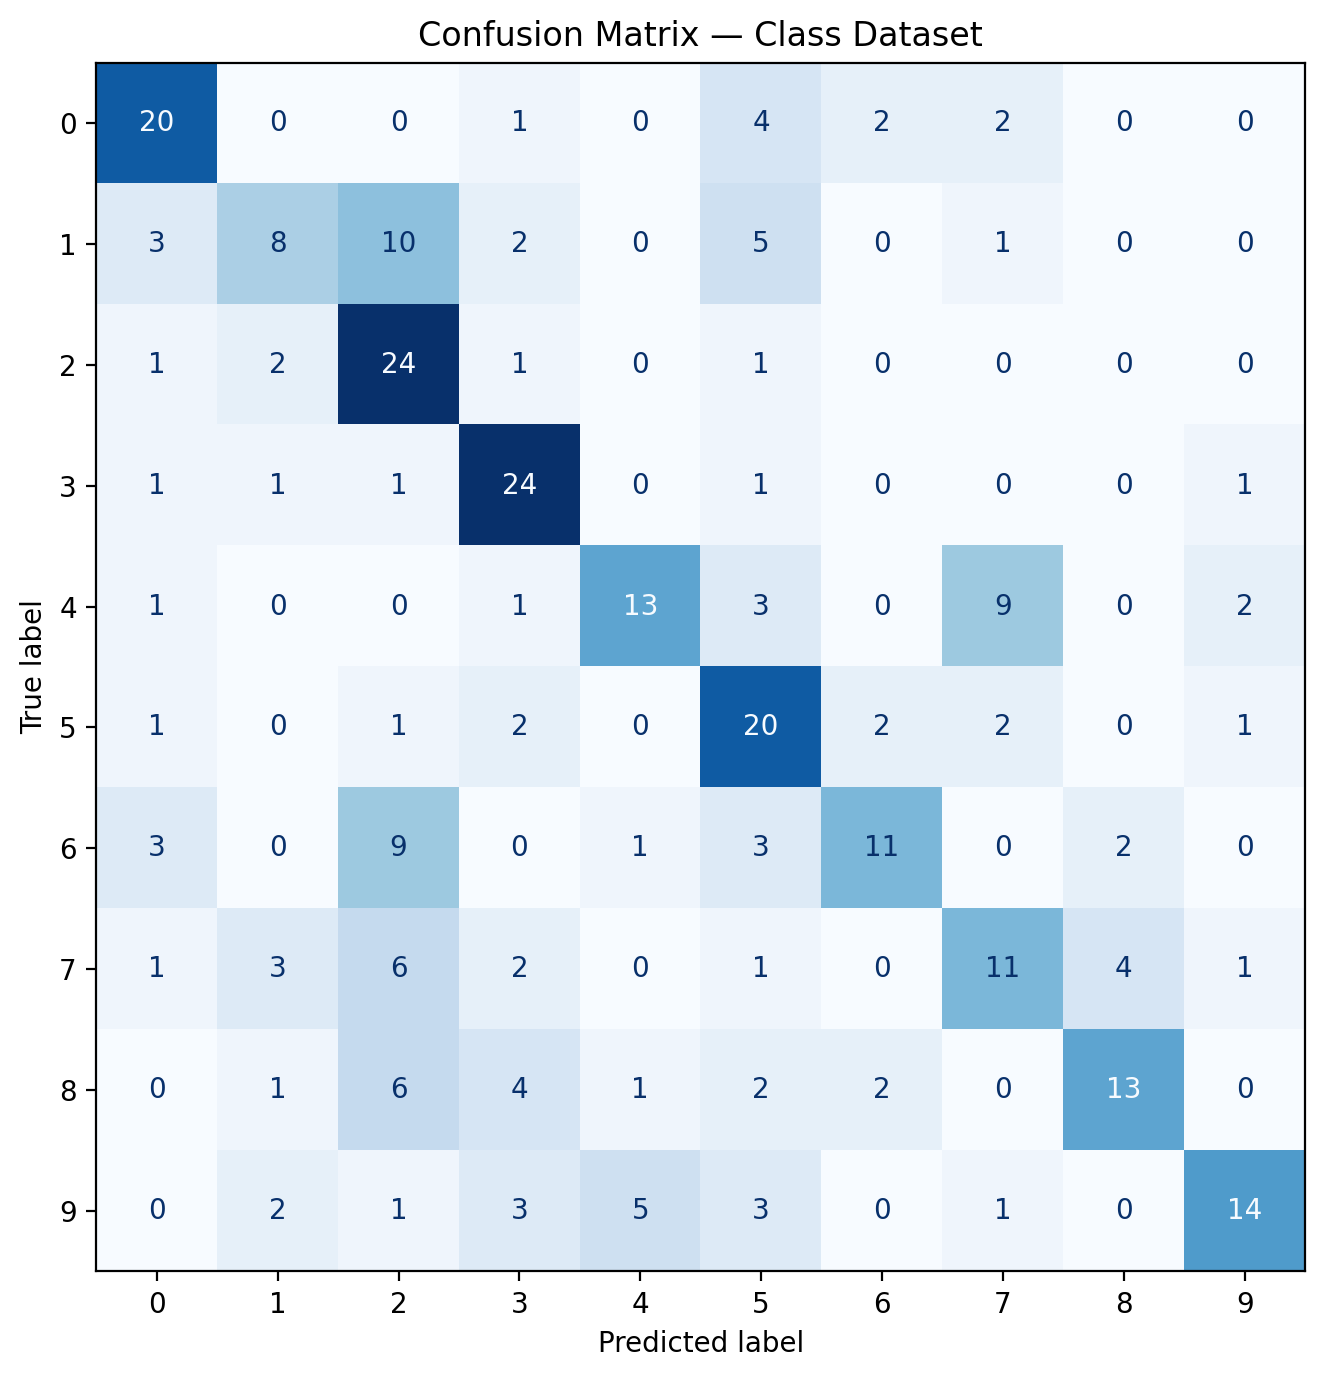

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Class Dataset')
plt.tight_layout()
plt.show()

In [30]:
ll = log_loss(y_true, probs)
print(f'Log-loss: {ll:.4f}')

Log-loss: 3.8193
